# Test Cases from Croad et al. (2023)

Two papers from Croad et al. (2023) describe the alternative version of the cyclone phase space.

- The first in [WCD](https://doi.org/10.5194/wcd-4-617-2023) shows two cases studies
- The second in [GRL](https://doi.org/10.1029/2023GL105993) shows a climatology

The code below produces a copy of Figure 2a from the first paper case studies. 

In [1]:
from cartopy.crs import NorthPolarStereo, PlateCarree
import huracanpy
import matplotlib.pyplot as plt
import metpy
import numpy as np
import xarray as xr

import cpys

In [ ]:
# Vertical levels for the snapshots in the snaps/ folder, in Pa
snaps_levels = np.concatenate([
    [1, 2, 3, 5, 7],
    [10, 20, 30, 50, 70],
    np.arange(100, 250, 25),
    np.arange(250, 750, 50),
    np.arange(750, 1025, 25),
]) * 100


/home/lsaffin/miniforge3/envs/core/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/home/lsaffin/miniforge3/envs/core/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


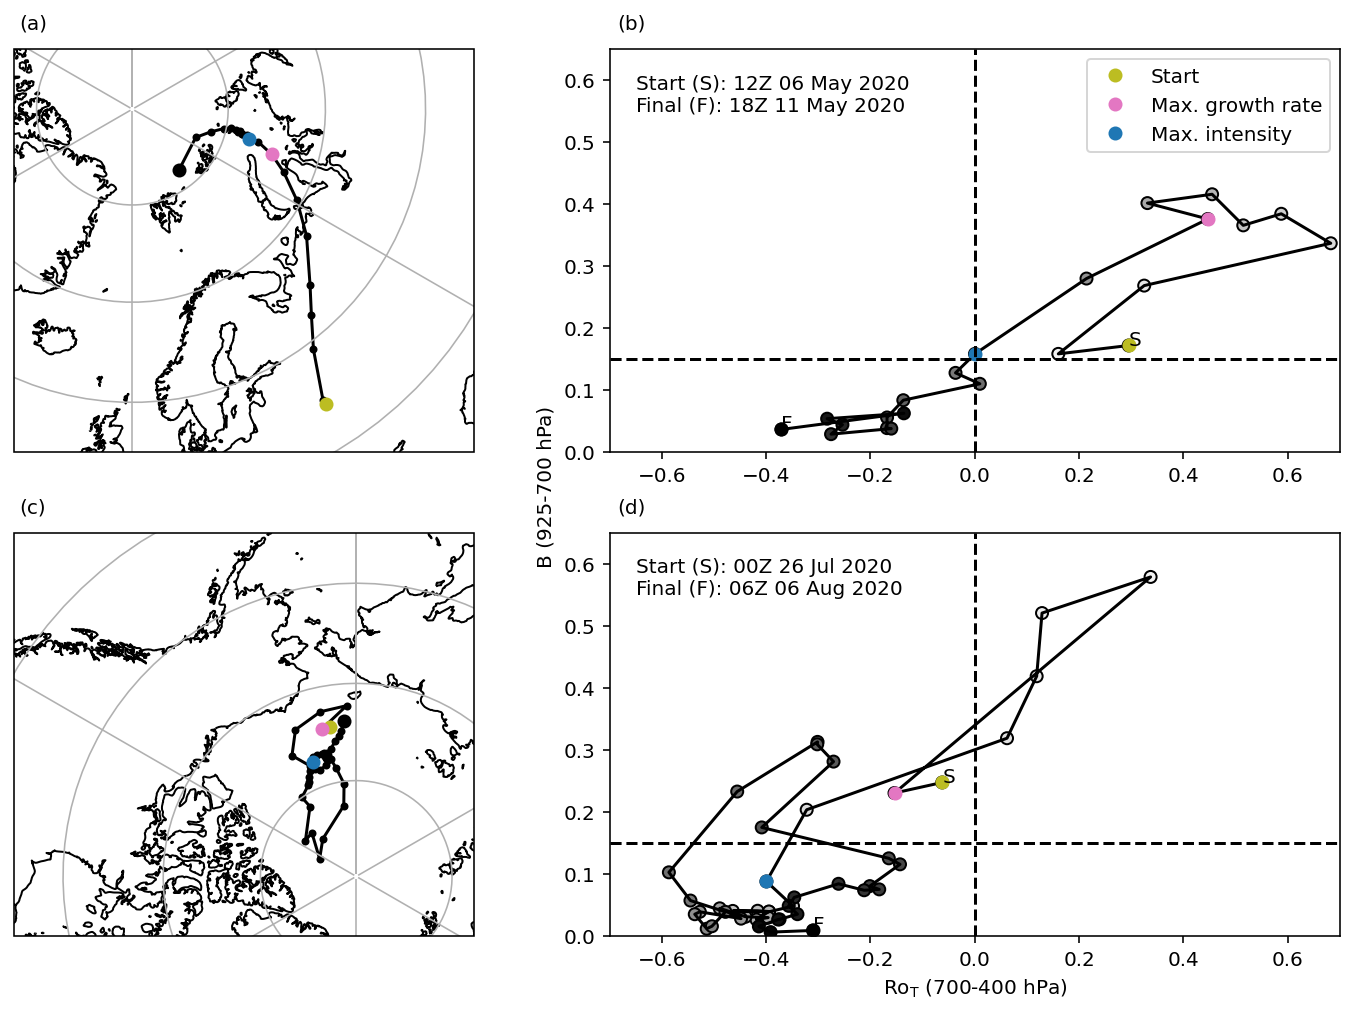

In [ ]:
fig, axes = plt.subplot_mosaic(
    """
    ab
    cd
    """,
    figsize=(12, 8),
    width_ratios=[2, 3],
    per_subplot_kw={
        subplot: dict(projection=NorthPolarStereo()) for subplot in ["a", "c"]
    },
)

for n, track_name in enumerate(["A", "B"]):
    track = track = huracanpy.load(f"tracks/Croad{track_name}_2020.csv")

    ds = xr.open_dataset(f"snaps/Croad{track_name}_2020.nc").assign(level=snaps_levels)

    ds.snap_ta.attrs["units"] = "kelvin"
    ds.level.attrs["units"] = "Pa"
    theta = metpy.calc.potential_temperature(
        ds.level.broadcast_like(ds.snap_ta), ds.snap_ta
    )

    rot = cpys.rot(ds.snap_vo, ds.snap_geopt / 9.81)
    b_max = cpys.b(
        theta.sel(level=slice(70000, 92500)).mean(dim="level"), ds.snap_lat, method="Croad"
    )

    if n == 0:
        ax1 = axes["a"]
        ax2 = axes["b"]
    else:
        ax1 = axes["c"]
        ax2 = axes["d"]

    ax1.plot(track.lon, track.lat, "-k.", transform=PlateCarree())
    ax1.gridlines()
    ax1.coastlines()

    ax2.plot(rot, b_max, "-k")
    ax2.scatter(rot, b_max, c=ds.snapshot, cmap="grey_r", edgecolors="k")

    max_intensity = track.slp.argmin()
    max_growth = np.diff(track.slp).argmin()
    for idx, marker, text, label in [
        (0, "oC8", "S", "Start"),
        (max_growth, "oC6", "", "Max. growth rate"),
        (max_intensity, "oC0", "", "Max. intensity"),
        (-1, "ok", "F", None),
    ]:
        ax1.plot(track.lon[idx], track.lat[idx], marker, transform=PlateCarree())
        ax2.plot(rot[idx], b_max[idx], marker, label=label)
        ax2.text(rot[idx], b_max[idx], text)

    timestr = track.time.dt.strftime("%HZ %d %b %Y").values
    ax2.text(-0.65, 0.55, f"Start (S): {timestr[0]}\nFinal (F): {timestr[-1]}")

    ax2.axvline(color="k", linestyle="--")
    ax2.axhline(0.15, color="k", linestyle="--")
    ax2.set_xlim(-0.7, 0.7)
    ax2.set_ylim(0, 0.65)

axes["b"].legend(loc="upper right")
axes["d"].set_xlabel("Ro$_\mathrm{T}$ (700-400 hPa)")
fig.text(0.435, 0.5, "B (925-700 hPa)", rotation="vertical", va="center")

axes["a"].set_extent([-20, 100, 55, 90], crs=PlateCarree())
axes["c"].set_extent([160, 280, 55, 90], crs=PlateCarree())

for ax in axes:
    axes[ax].text(0.01, 1.05, f"({ax})", transform=axes[ax].transAxes)